pip install tensorflow matplotlib numpy scikit-learn kagglehub

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
import os

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [7]:
path = kagglehub.dataset_download(
    "vbookshelf/rice-leaf-diseases"
)

print("Downloaded Dataset Path:")
print(path)

Downloaded Dataset Path:
C:\Users\gaura\.cache\kagglehub\datasets\vbookshelf\rice-leaf-diseases\versions\1


In [8]:
import os

folders = os.listdir(path)

print("Folders Inside Dataset:")
print(folders)

dataset_path = os.path.join(
    path,
    folders[0]
)

print("\nUsing Dataset Path:")
print(dataset_path)

Folders Inside Dataset:
['rice_leaf_diseases']

Using Dataset Path:
C:\Users\gaura\.cache\kagglehub\datasets\vbookshelf\rice-leaf-diseases\versions\1\rice_leaf_diseases


In [9]:

IMG_SIZE = 64
BATCH_SIZE = 16


In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="training",

    seed=123,

    image_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE
)


Found 120 files belonging to 3 classes.
Using 96 files for training.


In [11]:
# =========================
# STEP 6 : LOAD VALIDATION DATASET
# =========================

validation_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="validation",

    seed=123,

    image_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE
)

Found 120 files belonging to 3 classes.
Using 24 files for validation.


In [12]:
# =========================
# STEP 7 : CLASS NAMES
# =========================

class_names = train_dataset.class_names

print("\nClasses Found:")
print(class_names)

num_classes = len(class_names)


Classes Found:
['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [13]:
# =========================
# STEP 8 : NORMALIZATION
# =========================

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)


In [14]:

# =========================
# STEP 9 : PREFETCH
# =========================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [15]:
# =========================
# STEP 10 : BUILD CNN MODEL
# =========================

model = tf.keras.models.Sequential([

    tf.keras.Input(shape=(64,64,3)),


    # FIRST CNN LAYER
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),


    # SECOND CNN LAYER
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),


    # THIRD CNN LAYER
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),


    # FLATTEN LAYER
    tf.keras.layers.Flatten(),


    # DENSE LAYER
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),


    # DROPOUT
    tf.keras.layers.Dropout(0.5),


    # OUTPUT LAYER
    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )

])


In [16]:
# =========================
# STEP 11 : COMPILE MODEL
# =========================

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [17]:
# =========================
# STEP 12 : MODEL SUMMARY
# =========================

print("\nMODEL SUMMARY\n")

model.summary()




MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,587 (2.61 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# =========================
# STEP 13 : TRAIN MODEL
# =========================

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=50
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3958 - loss: 1.1329 - val_accuracy: 0.2917 - val_loss: 1.0995
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3542 - loss: 1.1046 - val_accuracy: 0.2917 - val_loss: 1.1510
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.4167 - loss: 1.0730 - val_accuracy: 0.2917 - val_loss: 1.1396
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.4479 - loss: 1.0817 - val_accuracy: 0.2500 - val_loss: 1.0879
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6042 - loss: 1.0186 - val_accuracy: 0.3750 - val_loss: 1.0762
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5104 - loss: 0.9936 - val_accuracy: 0.7500 - val_loss: 0.9446
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5104 - loss: 1.0239 - val_accuracy: 0.3750 - val_loss: 1.0273
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6979 - loss: 0.8534 - val_accuracy: 0.5000 - val_loss: 0.867

In [19]:

# =========================
# STEP 14 : EVALUATE MODEL
# =========================

loss, acc = model.evaluate(validation_dataset)

print("\nValidation Accuracy :", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8750 - loss: 0.4512

Validation Accuracy : 0.875


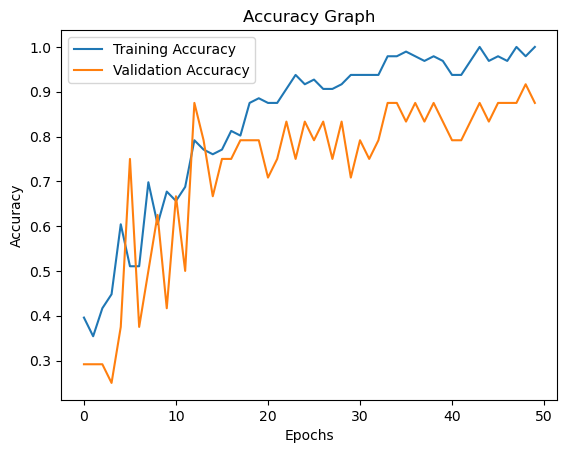

In [20]:
# =========================
# STEP 15 : ACCURACY GRAPH
# =========================

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("Accuracy Graph")

plt.legend()

plt.show()

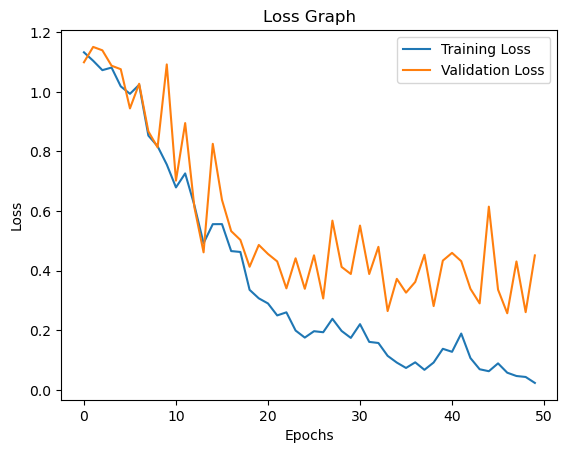

In [21]:
# =========================
# STEP 16 : LOSS GRAPH
# =========================

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Loss Graph")

plt.legend()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


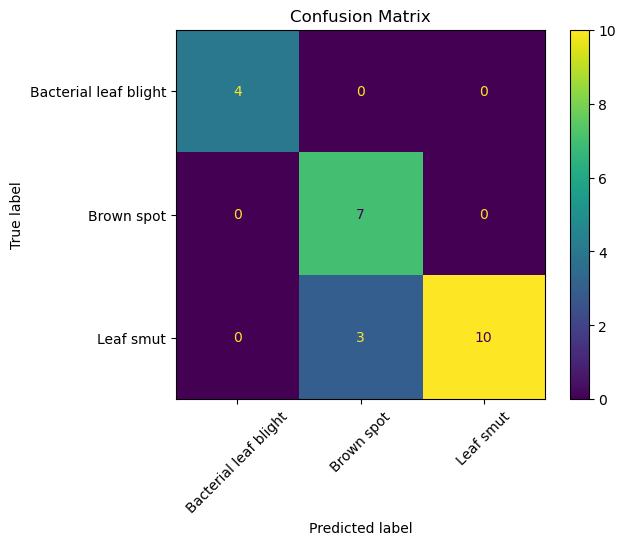

In [22]:
# =========================
# STEP 17 : CONFUSION MATRIX
# =========================

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names
)

disp.plot(
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.show()

In [23]:
# =========================
# STEP 18 : SAVE MODEL
# =========================

model.save("plant_disease_model.h5")

print("\nModel Saved Successfully")


Model Saved Successfully


In [24]:
# =========================
# STEP 19 : IMAGE PREDICTION
# =========================

# PATH OF TEST IMAGE
image_path = "images (6).jpg"


# LOAD IMAGE
img = tf.keras.utils.load_img(

    image_path,

    target_size=(64,64)
)


# CONVERT IMAGE TO ARRAY
img_array = tf.keras.utils.img_to_array(img)


# EXPAND DIMENSIONS
img_array = tf.expand_dims(img_array, 0)


# NORMALIZE IMAGE
img_array = img_array / 255.0


# PREDICT
prediction = model.predict(img_array)


# FIND PREDICTED CLASS
predicted_class = class_names[
    np.argmax(prediction)
]


# CONFIDENCE SCORE
confidence = 100 * np.max(prediction)


print("\nPredicted Disease :",predicted_class)


print("\nConfidence :")
print(confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Predicted Disease : Leaf smut

Confidence :
99.94702935218811
